# Summarizing text using LangChain
## Summarizing a document bigger than context window

The `LLM context window` refers to the maximum amount of text—comprising both instructions and context—that can be provided to a language model in a single prompt. Different LLMs support different token limits for this context window, where one token roughly corresponds to one word. For example, GPT-3.5 can process up to 16K tokens, GPT-4 and Claude 3 support up to 100K tokens, and newer models such as GPT-5 and Gemini can handle over 1 million tokens.

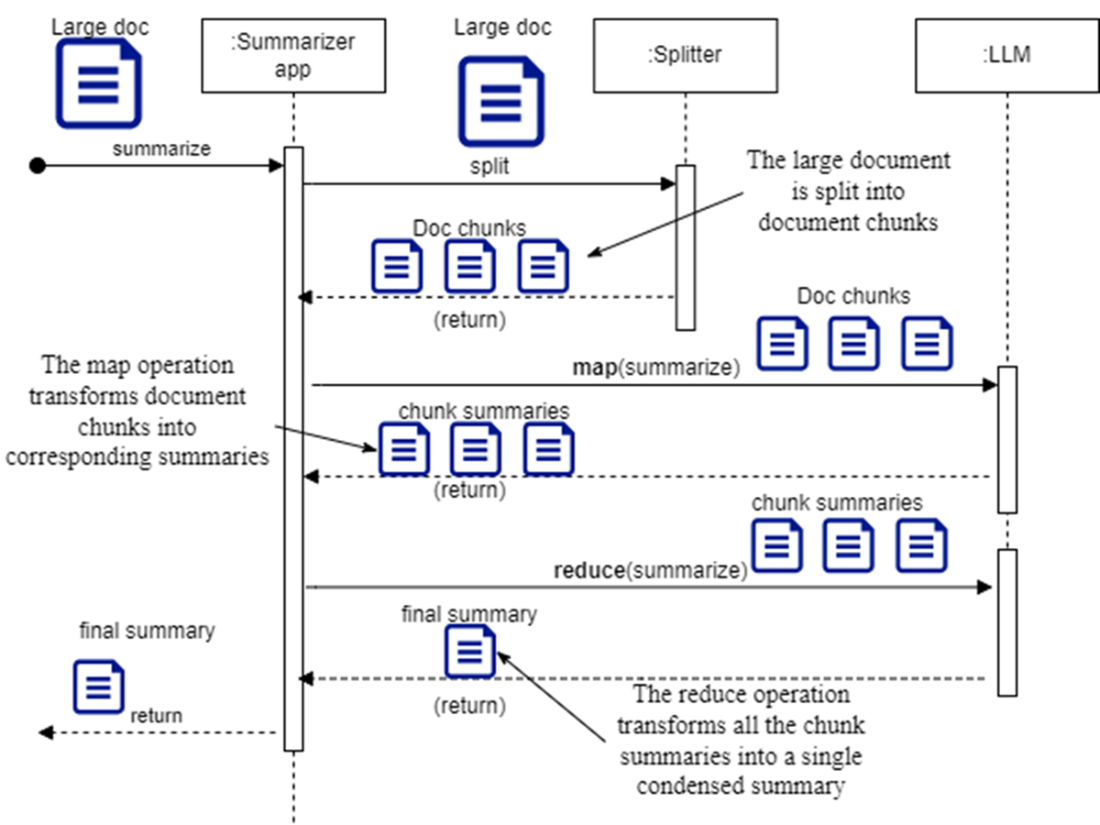

This workflow involves splitting the document into smaller segments, summarizing each one, and then summarizing the combined summaries.

To start, you need to split the text into chunks using a tokenizer. A tokenizer reads the text and breaks it into tokens, which are the smallest units of text, often parts of words. After tokenizing the document, the tokens are grouped into chunks of a specific size. This lets you control the content size being processed by the LLM and ensures the token count stays within your LLM's prompt limit. I'll show you how to use `TokenTextSplitter`, part of the tiktoken package, a tokenizer developed by OpenAI.

### Chunking the text into Document objects

In [1]:
with open("Paestum/Moby-Dick.txt", 'r', encoding='utf-8') as f:
    moby_dick_book = f.read()

In [2]:
from langchain_ollama import ChatOllama
from langchain_text_splitters import TokenTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnableParallel

In [3]:
llm = ChatOllama(model="qwen3.5:397b-cloud", temperature=0)



---

## 🏗️ Large Document Summarization: The Map-Reduce Flow

When a document is too long to fit into an LLM's context window (Prompt Limit), we use the **Map-Reduce** strategy. This allows the model to process massive amounts of data by breaking it down and then reconstructing the key insights.

### 1. The Architecture Overview

The flow is divided into three distinct functional stages:

---

### Phase 1: The Split (Data Preparation)

**Code:** `Splittext_chunks_chain`

* **Purpose:** To transform a single massive string into manageable "bite-sized" pieces.
* **Mechanism:** Uses `TokenTextSplitter` with a `chunk_size` of 3,000 tokens.
* **Overlap:** Includes a 100-token `chunk_overlap` to ensure context (like the end of a sentence) isn't lost between chunks.
* **Output:** A List of dictionaries:
`[{'chunk': 'text...'}, {'chunk': 'text...'}]`

---

### Phase 2: The Map (Parallel Processing)

**Code:** `summarize_map_chain.map()`

* **Purpose:** To summarize every chunk individually and simultaneously.
* **Mechanism:** The `.map()` operator triggers **Parallel Execution**. Each chunk is fed into the `summarize_chunk_prompt`.
* **Prompt Logic:** *"Write a concise summary of the following text..."*
* **Output:** A List of partial summaries:
`[{'summary': 'Summary A'}, {'summary': 'Summary B'}]`

---

### Phase 3: The Reduce (Final Synthesis)

**Code:** `summarize_reduce_chain`

* **Purpose:** To "collapse" all partial summaries into one final, coherent document.
* **Mechanism:** 1.  **Join:** It takes the list of summaries and joins them with newlines (`\n`).
2.  **Synthesis:** The combined text is sent to the `summarize_summaries_prompt`.
* **Prompt Logic:** *"Write a concise summary... which joins several summaries..."*
* **Final Result:** A single, high-quality summary of the entire original document.

---

### 🔄 Data Flow Summary Table

| Stage | Input | Transformation | Output |
| --- | --- | --- | --- |
| **Split** | Raw Text (Long) | Token-based chunking | `List[Dict]` of Text Chunks |
| **Map** | `List[Dict]` | LLM summarizes each chunk in parallel | `List[Dict]` of Summaries |
| **Reduce** | `List[Dict]` | Combine + Final LLM synthesis | **Single String (Final Summary)** |

> **Teacher's Note:** The `.map()` function is the engine here. It allows the chain to scale. Whether you have 5 chunks or 50, the "Map" phase handles them efficiently before the "Reduce" phase brings them home.

---

**Would you like me to add a section on how to handle the "Recursive Reduce" (in case the combined summaries are still too long for the final LLM call)?**

In [4]:
text_chunks_chain = (
    RunnableLambda(lambda x: 
        [
            {'chunk': text_chunk, }
            for text_chunk in TokenTextSplitter(chunk_size=3000, chunk_overlap=100).split_text(x)
        ]
    )
)

# Map
summarize_chunk_prompt_template = """
Write a concise summary of the following text, and include the main details.
Text: {chunk}
"""

summarize_chunk_prompt = PromptTemplate.from_template(summarize_chunk_prompt_template)
summarize_chunk_chain = summarize_chunk_prompt | llm

summarize_map_chain = (
    RunnableParallel (
        {
            'summary': summarize_chunk_chain | StrOutputParser()        
        }
    )
)
# Reduce
summarize_summaries_prompt_template = """
Write a coincise summary of the following text, which joins several summaries, and include the main details.
Text: {summaries}
"""

summarize_summaries_prompt = PromptTemplate.from_template(summarize_summaries_prompt_template)
summarize_reduce_chain = (
    RunnableLambda(lambda x: 
        {
            'summaries': '\n'.join([i['summary'] for i in x]), 
        })
    | summarize_summaries_prompt 
    | llm 
    | StrOutputParser()
)
map_reduce_chain = (
   text_chunks_chain
   | summarize_map_chain.map()
   | summarize_reduce_chain
)     

In [5]:
import textwrap

# generate and display the summary in a readable, wrapped format
summary = map_reduce_chain.invoke(moby_dick_book)

print("\n=== Final Summary ===\n")
print(textwrap.fill(summary, width=100))


=== Final Summary ===

In Herman Melville's *Moby-Dick*, the narrator Ishmael introduces himself as a common sailor who
goes to sea to combat depression, attributing his specific voyage to fate. Arriving in New Bedford,
he lodges at the Spouter-Inn, where he is forced to share a room with a harpooneer due to lack of
space. After initially attempting to sleep on a bench, Ishmael meets his bedfellow, Queequeg, late
at night. Though terrified by Queequeg's tattoos, pagan rituals, and tomahawk-pipe, Ishmael is
reassured by the landlord and decides it is safer to sleep with a sober cannibal than a drunken
Christian. The following morning, despite Queequeg's eccentric grooming habits, such as shaving with
a harpoon, Ishmael recognizes the harpooneer's innate civility and politeness.


In [10]:
from langchain_community.document_loaders import Docx2txtLoader
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import TextLoader

 
word_loader = Docx2txtLoader("Paestum/Paestum-Britannica.docx")
word_docs = word_loader.load()
 
pdf_loader = PyPDFLoader("Paestum/PaestumRevisited.pdf")
pdf_docs = pdf_loader.load()
 
txt_loader = TextLoader("Paestum/Paestum-Encyclopedia.txt")
txt_docs = txt_loader.load()

all_docs =  word_docs + pdf_docs + txt_docs
all_docs

[Document(metadata={'source': 'Paestum/Paestum-Britannica.docx'}, page_content='Paestum\n\nancient city, Italy\n\nPrint\xa0Cite\xa0Share\xa0Feedback\xa0\n\nAlso known as: Poseidonia\n\nWritten and fact-checked by\xa0\n\n\n\n\n\nThe Editors of Encyclopaedia Britannica\n\nLast Updated:\xa0Article History\n\n\n\n\n\nPaestum: Temple of Apollo\n\nSee all media\n\nCategory:\xa0Geography & Travel\n\nGreek:\xa0Poseidonia\n\nRelated Places:\n\n\xa0\n\nItaly\xa0ancient Greece\xa0Basilicata\n\nSee all related content →\n\nPaestum, Greek\xa0Poseidonia, ancient city in southern\xa0Italy\xa0near the west coast, 22 miles (35 km) southeast of modern\xa0Salerno\xa0and 5 miles (8 km) south of the Sele (ancient Silarus) River. Paestum is noted for its splendidly preserved Greek temples.\n\n\n\n\n\nVisit the ruins of the ancient Greek colony of Paestum and discover its history, culture, and society\n\nSee all videos for this article\n\nPoseidonia was probably founded about 600\xa0BC\xa0by Greek colonists 

In [9]:
doc_summary_template = """Write a concise summary of the following text:
{text}
DOC SUMMARY:"""
doc_summary_prompt = PromptTemplate.from_template(doc_summary_template)

doc_summary_chain = doc_summary_prompt | llm
refine_summary_template = """
Your must produce a final summary from the current refined summary
which has been generated so far and from the content of an additional document.
This is the current refined summary generated so far: {current_refined_summary}
This is the content of the additional document: {text}
Only use the content of the additional document if it is useful, 
otherwise return the current full summary as it is."""

refine_summary_prompt = PromptTemplate.from_template(refine_summary_template)

refine_chain = refine_summary_prompt | llm | StrOutputParser()


In [11]:
def refine_summary(docs):

    intermediate_steps = []
    current_refined_summary = ''
    for doc in docs:
        intermediate_step = \
           {"current_refined_summary": current_refined_summary, 
            "text": doc.page_content}
        intermediate_steps.append(intermediate_step)
        
        current_refined_summary = refine_chain.invoke(intermediate_step)
        
    return {"final_summary": current_refined_summary,
            "intermediate_steps": intermediate_steps}


In [12]:

full_summary = refine_summary(all_docs)
print(full_summary)

{'final_summary': "Paestum, originally known as Poseidonia, is an ancient city in southern Italy located southeast of Salerno. Founded around 600 BC by Achaean Greek colonists from Sybaris, it operated as an autonomous Greek polis for approximately 200 years. The city was endowed with a defensive wall featuring four gates and included an agora adorned with structures such as a bouleuterion and a heroon dedicated to the city's founder. Inside the walls, three Doric-style temples were erected in the sixth and fifth centuries (c. 530 BC–c. 460 BC), commonly referred to as Hera I, Hera II, and the Temple of Athena. This Paestum Order is characterized by the most exaggerated entasis of any Antique example, with very wide squat capitals on top of the shafts that emphasize a primitive effect. Poseidonia engaged in intense cultural and commercial exchange with the Greek world, Etruscans, and other Italic tribes. Before 400 BC, the city came under the control of the Lucanians, an Oscan-speaking